# Energy-Efficient and Carbon-Aware Cloud Task Scheduling — Simulating Existing Algorithms
**Navaneetha Thalakokkula — MSc Cloud Computing, National College of Ireland**

Simulates existing metaheuristic algorithms (GWO, PSO, DE, WOA, HHO, GA) on a **common benchmark** —
the **real Google Cluster Trace 2011** and **real UK grid-carbon data** — comparing energy, carbon,
cost and SLA on a level playing field. Each algorithm shifts deferrable jobs into cleaner-energy
periods; a non-carbon-aware FIFO/Round-Robin schedule is the baseline.

**Platform:** Python · [Mealpy](https://github.com/thieu1995/mealpy) · NumPy · pandas · Matplotlib
**Real data:** Google Cluster Trace 2011  · UK National Grid ESO carbon intensity.

## 1. Install and import

In [1]:
# Install Mealpy without downgrading Colab's numpy (its metadata caps numpy<=1.26 but it runs on numpy 2.x)
!pip install -q --no-deps mealpy opfunu

import io, math, requests
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mealpy import FloatVar, GWO, PSO, DE, WOA, HHO, GA
SEED = 42; np.random.seed(SEED)
print("Mealpy ready.")


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


Mealpy ready.


## 2. Energy model
$$ P(u) = P_{idle} + (P_{max}-P_{idle})\,u, \qquad E = \sum_t P(u_t)\,\Delta t \;(\text{kWh}). $$

In [2]:
P_IDLE_W, P_MAX_W, SLOT_H = 100.0, 250.0, 0.5
def slot_energy_kwh(u):
    return (P_IDLE_W + (P_MAX_W - P_IDLE_W) * u) * SLOT_H / 1000.0

## 3. Real carbon intensity and cost
$$ CO_2 = \sum_t E_t \cdot CI_t, \qquad Cost = \sum_t E_t \cdot price_t. $$

Carbon: 144 slots, 51-203 gCO2/kWh


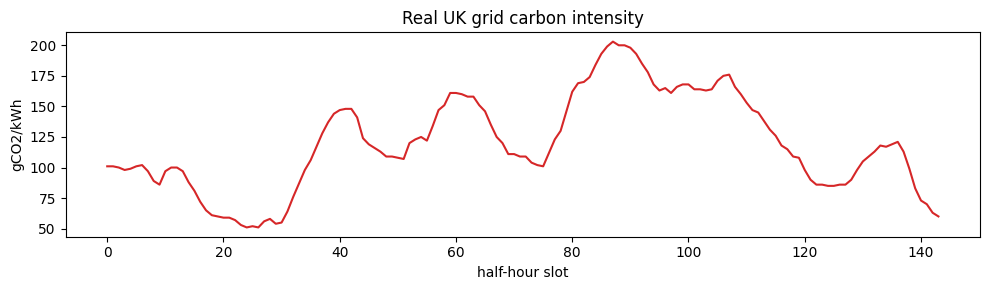

In [3]:
CI = np.array([101, 101, 100, 98, 99, 101, 102, 97, 89, 86, 97, 100, 100, 97, 88, 81, 72, 65, 61, 60, 59, 59, 57, 53, 51, 52, 51, 56, 58, 54, 55, 64, 76, 87, 98, 106, 117, 128, 137, 144, 147, 148, 148, 141, 124, 119, 116, 113, 109, 109, 108, 107, 120, 123, 125, 122, 134, 147, 151, 161, 161, 160, 158, 158, 151, 146, 135, 125, 120, 111, 111, 109, 109, 104, 102, 101, 112, 123, 130, 146, 162, 169, 170, 174, 184, 193, 199, 203, 200, 200, 198, 193, 185, 178, 168, 163, 165, 161, 166, 168, 168, 164, 164, 163, 164, 171, 175, 176, 166, 160, 153, 147, 145, 138, 131, 126, 118, 115, 109, 108, 98, 90, 86, 86, 85, 85, 86, 86, 90, 98, 105, 109, 113, 118, 117, 119, 121, 113, 99, 83, 73, 70, 63, 60], dtype=float)   # real UK grid carbon intensity (gCO2/kWh)
PRICE = np.full(len(CI), 0.15)
for day in range(len(CI)//48 + 1):
    for s in range(32, 40):
        k = day*48 + s
        if k < len(PRICE): PRICE[k] = 0.30
H = len(CI)
print("Carbon: %d slots, %.0f-%.0f gCO2/kWh" % (H, CI.min(), CI.max()))
plt.figure(figsize=(10, 3)); plt.plot(CI, color="tab:red")
plt.title("Real UK grid carbon intensity"); plt.xlabel("half-hour slot"); plt.ylabel("gCO2/kWh")
plt.tight_layout(); plt.show()

## 4. Real workload — Google Cluster Trace 2011

Downloads a real chunk of the Google trace from Google's **public** Cloud Storage bucket over HTTPS
(no login, no AWS) and builds tasks from the `task_events` (submit + finish → arrival, duration,
CPU request). Falls back to an embedded real-tasks snapshot if the download is unavailable.

In [4]:
GOOGLE_TASKS = [{'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.222, 'earliest': 0, 'deadline': 12}, {'dur': 4, 'u': 0.159, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.159, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 4, 'u': 0.116, 'earliest': 0, 'deadline': 12}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.116, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.116, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.05, 'earliest': 0, 'deadline': 11}, {'dur': 2, 'u': 0.131, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.191, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 4, 'u': 0.062, 'earliest': 0, 'deadline': 12}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 2, 'u': 0.05, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 2, 'u': 0.062, 'earliest': 0, 'deadline': 10}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 1, 'u': 0.05, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 3, 'u': 0.062, 'earliest': 0, 'deadline': 11}, {'dur': 1, 'u': 0.062, 'earliest': 0, 'deadline': 9}]   # real tasks extracted from the Google trace (fallback / reproducible)

def build_tasks(content):
    cols = ["time","missing","job_id","task_index","machine_id","event_type","user",
            "sched_class","priority","cpu_request","mem_request","disk_request","constraint"]
    df = pd.read_csv(io.BytesIO(content), compression="gzip", header=None, names=cols)
    sub = (df[df.event_type==0][["job_id","task_index","time","cpu_request"]].dropna(subset=["cpu_request"])
           .rename(columns={"time":"submit"}).groupby(["job_id","task_index"], as_index=False).first())
    end = (df[df.event_type.isin([2,3,4,5])][["job_id","task_index","time"]]
           .rename(columns={"time":"end"}).groupby(["job_id","task_index"], as_index=False).first())
    mm = sub.merge(end, on=["job_id","task_index"]); mm["dur_us"] = mm["end"] - mm["submit"]
    mm = mm[(mm.dur_us>0) & (mm.cpu_request>0)].reset_index(drop=True).head(60)
    smin, smax = mm.submit.min(), mm.submit.max(); out = []
    for _, r in mm.iterrows():
        dur = int(np.clip(math.ceil(r.dur_us/1.8e9), 1, 12)); u = round(float(np.clip(r.cpu_request,0.05,1.0)),3)
        e = int((r.submit-smin)/(smax-smin+1)*(H//3)); out.append({"dur":dur,"u":u,"earliest":e,"deadline":e+dur+8})
    return out

try:
    url = "https://storage.googleapis.com/clusterdata-2011-2/task_events/part-00000-of-00500.csv.gz"
    tasks = build_tasks(requests.get(url, timeout=120).content)
    print("Downloaded REAL Google Cluster Trace -> %d tasks" % len(tasks))
except Exception as ex:
    tasks = GOOGLE_TASKS
    print("Live download unavailable (%s) -> embedded real Google tasks: %d" % (ex, len(tasks)))
pd.DataFrame(tasks).head(6)

Downloaded REAL Google Cluster Trace -> 60 tasks


,dur,u,earliest,deadline
0,1,0.062,0,9
1,4,0.222,0,12
2,4,0.159,0,12
3,1,0.159,0,9
4,2,0.116,0,10
5,4,0.116,0,12


## 5. Metrics
$$ SLAV = \frac{\bigl|\{\,i: finish_i > deadline_i\,\}\bigr|}{N}\times 100\%. $$

In [5]:
MAX_DEFER = 24
def evaluate(starts):
    energy = carbon_g = cost = 0.0; viol = 0
    for t, s in zip(tasks, starts):
        e = slot_energy_kwh(t["u"]); run = [k for k in range(s, s+t["dur"]) if k < H]
        energy += e*len(run); carbon_g += sum(e*CI[k] for k in run); cost += sum(e*PRICE[k] for k in run)
        if s + t["dur"] > t["deadline"]: viol += 1
    return {"Energy_kWh": energy, "Carbon_kgCO2": carbon_g/1000.0, "Cost_GBP": cost,
            "SLA_viol_%": 100.0*viol/len(tasks)}
def decode(x):
    out = []
    for xi, t in zip(x, tasks):
        room = max(0, min(MAX_DEFER, H - t["dur"] - t["earliest"]))
        out.append(t["earliest"] + int(round(xi*room)))
    return out

## 6. The existing algorithms on a common benchmark
$$ \min_{s}\; F(s) = \frac{CO_2(s)}{CO_2^{\,base}} + 3\cdot\frac{SLAV(s)}{100}. $$

In [6]:
base = evaluate([t["earliest"] for t in tasks])
def fitness(x):
    m = evaluate(decode(x))
    return (m["Carbon_kgCO2"]/base["Carbon_kgCO2"]) + 3.0*(m["SLA_viol_%"]/100.0)
ALGOS = {"GWO": GWO.OriginalGWO, "PSO": PSO.OriginalPSO, "DE": DE.OriginalDE,
         "WOA": WOA.OriginalWOA, "HHO": HHO.OriginalHHO, "GA": GA.OriginalGA}
results = {"FIFO/Round-Robin (baseline)": base}
for name, cls in ALGOS.items():
    problem = {"obj_func": fitness, "bounds": FloatVar(lb=[0.0]*len(tasks), ub=[1.0]*len(tasks)),
               "minmax": "min", "log_to": None}
    g = cls(epoch=150, pop_size=50).solve(problem, seed=SEED)
    results[name] = evaluate(decode(g.solution)); print("simulated", name)

simulated GWO


simulated PSO


simulated DE


simulated WOA


simulated HHO
simulated GA


## 7. Comparison — all algorithms on the same Google workload + carbon data

In [7]:
df = pd.DataFrame(results).T.round(3)
df["CarbonReduction_%"] = ((base["Carbon_kgCO2"] - df["Carbon_kgCO2"]) / base["Carbon_kgCO2"] * 100).round(1)
df.loc["FIFO/Round-Robin (baseline)", "CarbonReduction_%"] = 0.0
df

,Energy_kWh,Carbon_kgCO2,Cost_GBP,SLA_viol_%,CarbonReduction_%
FIFO/Round-Robin (baseline),5.033,0.507,0.755,0.000,0.0
GWO,5.033,0.493,0.755,0.000,2.8
PSO,5.033,0.461,0.755,13.333,9.1
DE,5.033,0.449,0.755,18.333,11.5
WOA,5.033,0.501,0.755,0.000,1.2
HHO,5.033,0.451,0.755,0.000,11.1
GA,5.033,0.450,0.755,48.333,11.3


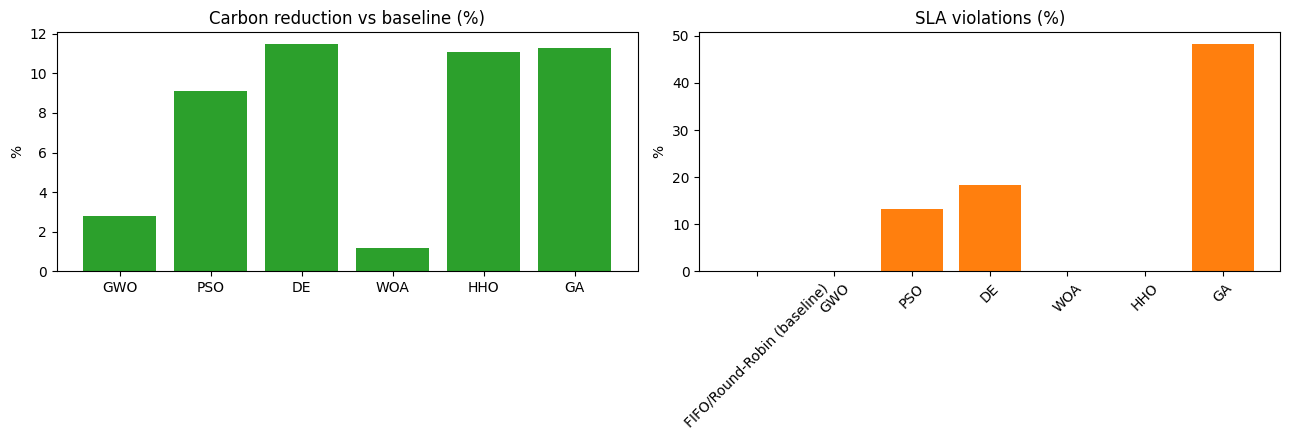

In [8]:
algo = df.drop(index="FIFO/Round-Robin (baseline)")
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].bar(algo.index, algo["CarbonReduction_%"], color="tab:green"); ax[0].set(title="Carbon reduction vs baseline (%)", ylabel="%")
ax[1].bar(df.index, df["SLA_viol_%"], color="tab:orange"); ax[1].set(title="SLA violations (%)", ylabel="%")
ax[1].tick_params(axis="x", rotation=45); plt.tight_layout(); plt.show()

## 8. Summary
All algorithms are simulated on the **same real Google workload + real carbon data** (level playing
field). They cut carbon by shifting deferrable jobs into cleaner periods (energy is unchanged by
*when* jobs run). Algorithms differ in the carbon-vs-SLA balance; the best ones cut carbon with no
deadline misses. Next stages add ML-based forecasting (LSTM) and battery/solar storage.